# Parametros Globales

In [2]:
# =========================
# Parámetros globales
# =========================

RANDOM_STATE = 42
TEST_SIZE = 0.2

# Métricas
SCORING_REGRESSION = ["rmse", "mae", "r2"]
SCORING_CLASSIFICATION = ["accuracy", "precision", "recall", "f1"]

# KNN
KNN_N_NEIGHBORS = 5
KNN_WEIGHTS = "distance"

# Random Forest
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH = None

# Logistic Regression
LR_MAX_ITER = 1000
LR_SOLVER = "lbfgs"

# SVC
SVC_C = 1.0
SVC_KERNEL = "rbf"
SVC_GAMMA = "scale"

# Paths
METRICS_PATH = "models/metrics_summary.csv"

# Librerias

In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

os.makedirs("models", exist_ok=True)

# Importar Dataset

In [4]:
url = "https://raw.githubusercontent.com/ChurnGuard/ChurnInsight/refs/heads/main/data-science/data/final/customer_dataset_for_ml.csv"
database = pd.read_csv(url)

database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 54 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          5000 non-null   object 
 1   age                                  5000 non-null   int64  
 2   membership_years                     5000 non-null   int64  
 3   number_of_children                   5000 non-null   int64  
 4   quantity                             5000 non-null   float64
 5   unit_price                           5000 non-null   float64
 6   avg_purchase_value                   5000 non-null   float64
 7   purchase_frequency                   5000 non-null   float64
 8   avg_discount_used                    5000 non-null   float64
 9   online_purchases                     5000 non-null   int64  
 10  in_store_purchases                   5000 non-null   int64  
 11  total_sales                   

# Correlaciones de Pares

In [5]:
correlation_matrix = database.corr(numeric_only=True)
correlation_pairs = correlation_matrix.abs().unstack()

# Eliminar autocorrelaciones (correlación de una variable consigo misma)
correlation_pairs = correlation_pairs[correlation_pairs.index.get_level_values(0) != correlation_pairs.index.get_level_values(1)]

# Eliminar pares duplicados (A,B) y (B,A)
correlation_pairs = correlation_pairs.drop_duplicates()
top_correlations = correlation_pairs.sort_values(ascending=False)
print(top_correlations.head(50))

avg_purchase_value           total_sales                            0.997180
promotion_effectiveness      promotion_type_no_promotion            0.896817
quantity                     avg_purchase_value                     0.831184
                             total_sales                            0.830526
membership_years             purchase_frequency                     0.766617
quantity                     promotion_effectiveness                0.739325
promotion_effectiveness      days_since_last_purchase               0.738124
total_sales                  promotion_effectiveness                0.645556
quantity                     promotion_type_no_promotion            0.644680
avg_purchase_value           promotion_effectiveness                0.641503
days_since_last_purchase     promotion_type_no_promotion            0.634145
avg_discount_used            in_store_purchases                     0.595408
unit_price                   avg_purchase_value                     0.564881

# Cambios al Dataset

### Features eliminadas



*   customer_id: No aporta valor a la creacion de modelos.
*   transaction_date: Alta correlacion con days_since_last_purchase
*   last_purchase_date: Alta correlación con days_since_last_purchase
*   total_sales: Alta correlación con avg_purchase_value
*   promotion_type_no_promotion: Alta correlacion con promotion_effectiveness






In [6]:
# =========================
# Limpieza de columnas
# =========================

# Copia para no modificar el dataset original
database_clean = database.copy()

# 1. Eliminar columnas no deseadas
columns_to_drop = [
    "customer_id",
    "transaction_date",
    "last_purchase_date",
    "promotion_type_no_promotion",
    "total_sales"
]

database_clean = database_clean.drop(columns=columns_to_drop)

database_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 49 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  5000 non-null   int64  
 1   membership_years                     5000 non-null   int64  
 2   number_of_children                   5000 non-null   int64  
 3   quantity                             5000 non-null   float64
 4   unit_price                           5000 non-null   float64
 5   avg_purchase_value                   5000 non-null   float64
 6   purchase_frequency                   5000 non-null   float64
 7   avg_discount_used                    5000 non-null   float64
 8   online_purchases                     5000 non-null   int64  
 9   in_store_purchases                   5000 non-null   int64  
 10  total_transactions                   5000 non-null   int64  
 11  total_items_purchased         

# Separacion de Features y Target

In [7]:
TARGET_COLUMN = "churn"

X_features_final = database_clean.drop(columns=[TARGET_COLUMN])
y = database_clean[TARGET_COLUMN]

# Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features_final,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Funcion Train_and_Log_model()

In [9]:
def train_and_log_model(
    model,
    model_name: str,
    X_train,
    y_train,
    X_test,
    y_test,
    metrics_path: str = METRICS_PATH
):
    """
    Entrena un modelo, evalúa métricas estándar y las guarda para comparación.
    """

    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicción
    y_pred = model.predict(X_test)

    # Métricas estándar
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

    # Guardado
    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv(
        metrics_path,
        mode="a",
        header=not os.path.exists(metrics_path),
        index=False
    )

    return metrics

# KNN


In [10]:
knn = KNeighborsClassifier(
    n_neighbors=KNN_N_NEIGHBORS,
    weights=KNN_WEIGHTS
)

model_name_knn = "knn_v1_baseline"

metrics_knn = train_and_log_model(
    model=knn,
    model_name=model_name_knn,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

metrics_knn

{'model': 'knn_v1_baseline',
 'accuracy': 0.967,
 'precision': 0.9256756756756757,
 'recall': 0.9614035087719298,
 'f1': 0.9432013769363167}

# Random Forest

In [11]:
rf = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_name_rf = "rf_v1_baseline"

metrics_rf = train_and_log_model(
    model=rf,
    model_name=model_name_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

metrics_rf

{'model': 'rf_v1_baseline',
 'accuracy': 0.983,
 'precision': 1.0,
 'recall': 0.9403508771929825,
 'f1': 0.969258589511754}

# Logistic Regression

In [12]:
logreg = LogisticRegression(
    max_iter=LR_MAX_ITER,
    solver=LR_SOLVER,
    random_state=RANDOM_STATE
)

model_name_logreg = "logreg_v1_baseline"

metrics_logreg = train_and_log_model(
    model=logreg,
    model_name=model_name_logreg,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

metrics_logreg

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'model': 'logreg_v1_baseline',
 'accuracy': 0.853,
 'precision': 0.8108108108108109,
 'recall': 0.631578947368421,
 'f1': 0.7100591715976331}

# Support Vector Classifier (SVC)

In [13]:
svc = SVC(
    C=SVC_C,
    kernel=SVC_KERNEL,
    gamma=SVC_GAMMA,
    random_state=RANDOM_STATE
)

model_name_svc = "svc_v1_baseline"

metrics_svc = train_and_log_model(
    model=svc,
    model_name=model_name_svc,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

metrics_svc

{'model': 'svc_v1_baseline',
 'accuracy': 0.692,
 'precision': 0.27450980392156865,
 'recall': 0.04912280701754386,
 'f1': 0.08333333333333333}

# Comparacion de Modelos

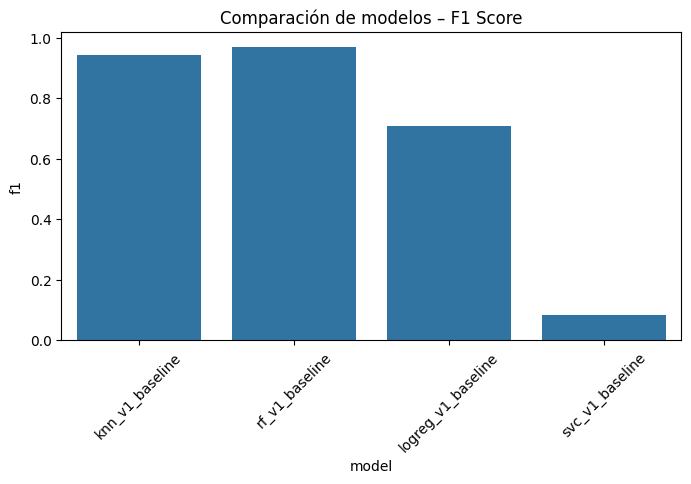

In [14]:
metrics_df = pd.read_csv(METRICS_PATH)
metrics_df

plt.figure(figsize=(8, 4))
sns.barplot(
    data=metrics_df,
    x="model",
    y="f1"
)
plt.title("Comparación de modelos – F1 Score")
plt.xticks(rotation=45)
plt.show()

# Análisis de los Modelos

En este proyecto se evaluaron cuatro modelos de clasificación para la predicción de churn, utilizando el mismo pipeline de entrenamiento, métricas estandarizadas y un conjunto de datos común. La métrica principal de comparación fue el F1-score, ya que este problema requiere un equilibrio entre la capacidad del modelo para identificar correctamente a los clientes que abandonan (recall) y la precisión de dichas predicciones (precision).

Los resultados obtenidos fueron los siguientes:

* K-Nearest Neighbors (KNN): F1 = 0.94

* Random Forest: F1 = 0.97

* Logistic Regression: F1 = 0.71

* Support Vector Classifier (SVC): F1 = 0.08

### K-Nearest Neighbors (KNN)
KNN mostró un desempeño alto en términos de F1-score, lo que sugiere que el churn puede ser identificado eficazmente mediante la similitud entre observaciones. Este resultado indica que existen patrones locales claros en los datos que permiten diferenciar a los clientes que abandonan de aquellos que permanecen. Sin embargo, al tratarse de un modelo basado en distancias, su comportamiento está estrechamente ligado a la representación del espacio de features y puede verse afectado por cambios en la distribución de los datos.

### Random Forest
Random Forest obtuvo el mejor desempeño global entre los modelos evaluados. Su capacidad para modelar relaciones no lineales y capturar interacciones complejas entre variables le permite adaptarse de manera más natural a la estructura del problema de churn. Además, el enfoque de ensamble contribuye a reducir la varianza del modelo y a mejorar su capacidad de generalización, logrando un balance superior entre precision y recall, reflejado en el F1-score más alto del conjunto.

### Logistic Regression
El desempeño de la regresión logística fue limitado debido a su supuesto de linealidad entre las variables explicativas y la probabilidad de churn. Dado que el abandono de clientes es un fenómeno influenciado por múltiples factores que interactúan de forma no lineal y dependen de umbrales de comportamiento, este modelo no logra capturar adecuadamente la complejidad subyacente del problema, lo que se refleja en un F1-score moderado.

### Support Vector Classifier (SVC)
El bajo F1-score obtenido por SVC indica una pobre capacidad de generalización en este contexto. Este modelo es especialmente sensible a la escala de las variables, al ruido y a la dimensionalidad del espacio de features. En este dataset, dichas características dificultan la construcción de un margen de separación efectivo, lo que se traduce en un desempeño muy bajo, particularmente en términos de recall.

# Modelo Ganador
Considerando tanto el desempeño cuantitativo como la adecuación conceptual de los modelos al problema de churn, Random Forest se selecciona como el modelo final para este proyecto. Su rendimiento superior, junto con su robustez frente a la complejidad de los datos, lo posiciona como la alternativa más confiable y efectiva para la predicción de abandono de clientes en este contexto.

# Serialización del Modelo Ganador


In [15]:
model_artifact = {
    "model": rf,
    "features": X_train.columns.tolist(),
    "model_name": model_name_rf
}

joblib.dump(
    model_artifact,
    f"models/{model_name_rf}.joblib"
)

['models/rf_v1_baseline.joblib']